In [53]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from google.colab import files



# 1. Data loading

In [54]:
# Define dataset path
path = kagglehub.dataset_download("mkechinov/ecommerce-events-history-in-electronics-store")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-events-history-in-electronics-store' dataset.
Path to dataset files: /kaggle/input/ecommerce-events-history-in-electronics-store


In [2]:
# Define file name
os.listdir(path)

['events.csv']

In [3]:
# Download dataset
file_path = os.path.join(path, "events.csv")
df = pd.read_csv(file_path)

# 2. Data Inspection

In [4]:
# Data overview
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


In [5]:
# Convert the event_time field to the datetime data type
df['event_time'] = pd.to_datetime(df['event_time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     885129 non-null  datetime64[ns, UTC]
 1   event_type     885129 non-null  object             
 2   product_id     885129 non-null  int64              
 3   category_id    885129 non-null  int64              
 4   category_code  648910 non-null  object             
 5   brand          672765 non-null  object             
 6   price          885129 non-null  float64            
 7   user_id        885129 non-null  int64              
 8   user_session   884964 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 60.8+ MB


### Dataset Description

The dataset contains **885,129 records** and **9 fields** describing user behavior
in an online store (views, cart additions, purchases).

| Field | Type | Description |
|---|---|---|
| `event_time` | object | Event timestamp — requires conversion to datetime |
| `event_type` | object | Event type: view, cart, purchase |
| `product_id` | int64 | Product ID |
| `category_id` | int64 | Category ID |
| `category_code` | object | Category name — contains missing values |
| `brand` | object | Product brand — contains missing values |
| `price` | float64 | Product price |
| `user_id` | int64 | User ID |
| `user_session` | object | User session ID |

**Issues identified requiring data cleaning:**
- `event_time` — incorrect data type (object instead of datetime)
- `category_code` — 236,219 missing values (~26%)
- `brand` — 212,364 missing values (~24%)
- `user_session` — 165 missing values (negligible amount)

# 3. Data cleaning

In [6]:
# missing values per column
print(df.isna().sum())

event_time            0
event_type            0
product_id            0
category_id           0
category_code    236219
brand            212364
price                 0
user_id               0
user_session        165
dtype: int64


In [7]:
# share of missing values per column
print(df.isna().sum() / df.shape[0] * 100)

event_time        0.000000
event_type        0.000000
product_id        0.000000
category_id       0.000000
category_code    26.687522
brand            23.992435
price             0.000000
user_id           0.000000
user_session      0.018641
dtype: float64


Missing values were identified in three fields:

- `category_code` — 236,219 missing values (~26.7%)
- `brand` — 212,364 missing values (~24.0%)
- `user_session` — 165 missing values (<0.1%)

The `category_code` and `brand` fields require separate handling; `user_session` has a negligible number of missing values.

In [8]:
# drop rows with missing user_session
df = df.dropna(subset=['user_session'])

In [9]:
# fill missing values in the category_code and brand fields with 'unknown'
df[['brand', 'category_code']] = df[['brand', 'category_code']].fillna('unknown')

In [10]:
# verify missing values
print(df.isna().sum())

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64


In [11]:
# сlean text columns: remove extra spaces and dots from both ends and convert to lowercase
df = df.apply(lambda x: x.str.strip().str.strip('.').str.lower() if x.dtype == "object" else x)

In [12]:
# check for duplicates across all columns
# count duplicate rows
dublic_prod = df.duplicated().sum()
print(f"Number of duplicates (by all columns): {dublic_prod}")

Number of duplicates (by all columns): 652


In [13]:
# Drop duplicates
df = df.drop_duplicates()

# Verify result
print(f"Duplicates after deletion: {df.duplicated().sum()}")

Duplicates after deletion: 0


In [14]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,unknown,31.90,1515915625519388267,ljujvlejpt
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdiclunnry
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,unknown,unknown,9.81,1515915625513238515,4tmarhtxqy
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,agfyrngc08
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,unknown,cameronsino,15.87,1515915625510743344,aa4mmk0kwq


In [15]:
# Check for negative or zero prices
print(df[df['price'] <= 0]['price'].value_counts())

Series([], Name: count, dtype: int64)


# 4. Feature Engineering

In [16]:
# Removing timezone information to prevent UserWarnings and ensure compatibility
df['event_time'] = df['event_time'].dt.tz_localize(None)

# Extracting date without time for daily trend analysis
df['event_date'] = df['event_time'].dt.normalize()

# Creating month-year labels for monthly aggregation
df['month'] = df['event_time'].dt.strftime('%b %Y')

# Extracting the hour component for hourly activity analysis
df['event_hour'] = df['event_time'].dt.hour

# Extracting day names for weekly performance comparison
df['day_of_week'] = df['event_time'].dt.day_name()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 884312 entries, 0 to 885128
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   event_time     884312 non-null  datetime64[ns]
 1   event_type     884312 non-null  object        
 2   product_id     884312 non-null  int64         
 3   category_id    884312 non-null  int64         
 4   category_code  884312 non-null  object        
 5   brand          884312 non-null  object        
 6   price          884312 non-null  float64       
 7   user_id        884312 non-null  int64         
 8   user_session   884312 non-null  object        
 9   event_date     884312 non-null  datetime64[ns]
 10  month          884312 non-null  object        
 11  event_hour     884312 non-null  int32         
 12  day_of_week    884312 non-null  object        
dtypes: datetime64[ns](2), float64(1), int32(1), int64(3), object(6)
memory usage: 91.1+ MB


In [18]:
# Extract main category and product type from category_code by adding new columns: main_category and product_type
df['main_category'] = df['category_code'].str.split('.').str[0]
df['product_type'] = df['category_code'].str.split('.').str[-1]
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,month,event_hour,day_of_week,main_category,product_type
0,2020-09-24 11:57:06,view,1996170,2144415922528452715,electronics.telephone,unknown,31.90,1515915625519388267,ljujvlejpt,2020-09-24,Sep 2020,11,Thursday,electronics,telephone
1,2020-09-24 11:57:26,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdiclunnry,2020-09-24,Sep 2020,11,Thursday,computers,cooler
2,2020-09-24 11:57:27,view,215454,2144415927158964449,unknown,unknown,9.81,1515915625513238515,4tmarhtxqy,2020-09-24,Sep 2020,11,Thursday,unknown,unknown
3,2020-09-24 11:57:33,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,agfyrngc08,2020-09-24,Sep 2020,11,Thursday,computers,printer
4,2020-09-24 11:57:36,view,3658723,2144415921169498184,unknown,cameronsino,15.87,1515915625510743344,aa4mmk0kwq,2020-09-24,Sep 2020,11,Thursday,unknown,unknown


#5. Exploratory Data Analysis

In [19]:
# Check unique product types within each main category
category_structure = df.groupby('main_category')['product_type'].unique()

for category, products in category_structure.items():
    print(f"--- {category.upper()} ---")
    print(f"{', '.join(products)}\n")

--- ACCESSORIES ---
bag, briefcase

--- APPAREL ---
glove

--- APPLIANCES ---
steam_cleaner, juicer, sewing_machine, vacuum, kettle, microwave, coffee_machine, blender, fryer, iron, air_heater, mixer, washer, meat_grinder, grill, steam_cooker, coffee_grinder, massager, hair_cutter, fan, scales, toster, refrigerators

--- AUTO ---
player, alarm, window, radar, parktronic, gps, videoregister, compressor, immobilizer, light, winch

--- COMPUTERS ---
cooler, printer, desktop, router, motherboard, keyboard, hdd, power_supply, cpu, scanner, camera, nas, network_adapter, joystick, wifi, videocards, mouse, tv_tuner, vr, notebook, monitor, ebooks, cdrw, sound_card, gaming

--- CONSTRUCTION ---
saw, welding, screw, pump, soldering, drill, light, wrench, heater, generator, painting

--- COUNTRY_YARD ---
cultivator, weather_station, lawn_mower, watering

--- ELECTRONICS ---
telephone, tv, video, acoustic, tablet, dictaphone, clocks, headphone, projector, microphone, tv_remote, piano, calculator, p

In [20]:
# Define a list of categories that match the project's theme
target_categories = ['computers', 'electronics', 'accessories', 'stationery']

# Filter data
df_it = df[df['main_category'].isin(target_categories)].copy()


In [21]:
df_it.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,month,event_hour,day_of_week,main_category,product_type
0,2020-09-24 11:57:06,view,1996170,2144415922528452715,electronics.telephone,unknown,31.90,1515915625519388267,ljujvlejpt,2020-09-24,Sep 2020,11,Thursday,electronics,telephone
1,2020-09-24 11:57:26,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdiclunnry,2020-09-24,Sep 2020,11,Thursday,computers,cooler
3,2020-09-24 11:57:33,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,agfyrngc08,2020-09-24,Sep 2020,11,Thursday,computers,printer
6,2020-09-24 11:58:23,view,3791349,2144415935086199225,computers.desktop,unknown,215.41,1515915625519388877,j1t6siyxiv,2020-09-24,Sep 2020,11,Thursday,computers,desktop
7,2020-09-24 11:58:24,view,716611,2144415923694469257,computers.network.router,d-link,53.14,1515915625519388882,kvbeydpcbw,2020-09-24,Sep 2020,11,Thursday,computers,router


After reviewing the category structure and the products within them, the data was filtered
according to the project scope. The new dataset `df_it` contains only relevant categories:
**computers, electronics, accessories, stationery**.

#**5.1. Sales performance analysis**

In [22]:
# 5.1.1 Total revenue
# Filter purchase events
purchases = df_it[df_it['event_type'] == 'purchase']

# Calculate total revenue
total_purchases = purchases['price'].sum()
print(f'Total revenue:  {total_purchases}')

Total revenue:  4290938.91


In [23]:
# 5.1.2 CR (Conversion Rate)
# Number of sessions with purchases
sessions_with_purchase = purchases['user_session'].nunique()

# Total number of sessions
total_sessions = df_it['user_session'].nunique()

# Calculate overall conversion rate
CR = round(sessions_with_purchase / total_sessions * 100, 2)
print(f'Conversion Rate: {CR}%')

Conversion Rate: 6.2%


In [24]:
# 5.1.3 Conversion rate by categories
# Group sessions by category
categ_groped = df_it.groupby('main_category')['user_session'].nunique().sort_values(ascending=False).reset_index()

# Group purchase sessions by category
categ_groped_purch = purchases.groupby('main_category')['user_session'].nunique().sort_values(ascending=False).reset_index()

# Merge dataframes
categ_cr = categ_groped.merge(categ_groped_purch, on='main_category', how='left')
categ_cr.columns = ['main_category', 'total_sessions', 'purchase_sessions']

# Calculate conversion rate by category
categ_cr['CR_%'] = (categ_cr['purchase_sessions'] / categ_cr['total_sessions'] * 100).round(2)
print('Conversion rate by categories:\n')
print(categ_cr.sort_values('CR_%', ascending=False))

Conversion rate by categories:

  main_category  total_sessions  purchase_sessions  CR_%
0     computers          149366              10964  7.34
2    stationery           27114               1748  6.45
1   electronics          103702               4679  4.51
3   accessories            1312                 38  2.90


In [25]:
 # 5.1.4 AOV (Average Order Value)
session_revenue = purchases.groupby(['main_category', 'user_session'])['price'].sum().reset_index()
AOV = session_revenue.groupby('main_category')['price'].mean().round(2).reset_index()
AOV.columns = ['main_category', 'AOV']

print(AOV.sort_values('AOV', ascending=False))

  main_category     AOV
1     computers  340.10
2   electronics   96.25
3    stationery   62.74
0   accessories   54.85


In [26]:
# 5.1.5 RPV (Revenue per Visitor)
# Total revenue by category
category_revenue = purchases.groupby('main_category')['price'].sum()

# Number of unique sessions by category
category_sessions = df_it.groupby('main_category')['user_session'].nunique()

# Calculate revenue per visitor by category
RPV_categ = (category_revenue / category_sessions).round(2).reset_index()
RPV_categ.columns = ['main_category', 'RPV']

print(RPV_categ.sort_values('RPV', ascending=False))


  main_category    RPV
1     computers  24.96
2   electronics   4.34
3    stationery   4.04
0   accessories   1.59


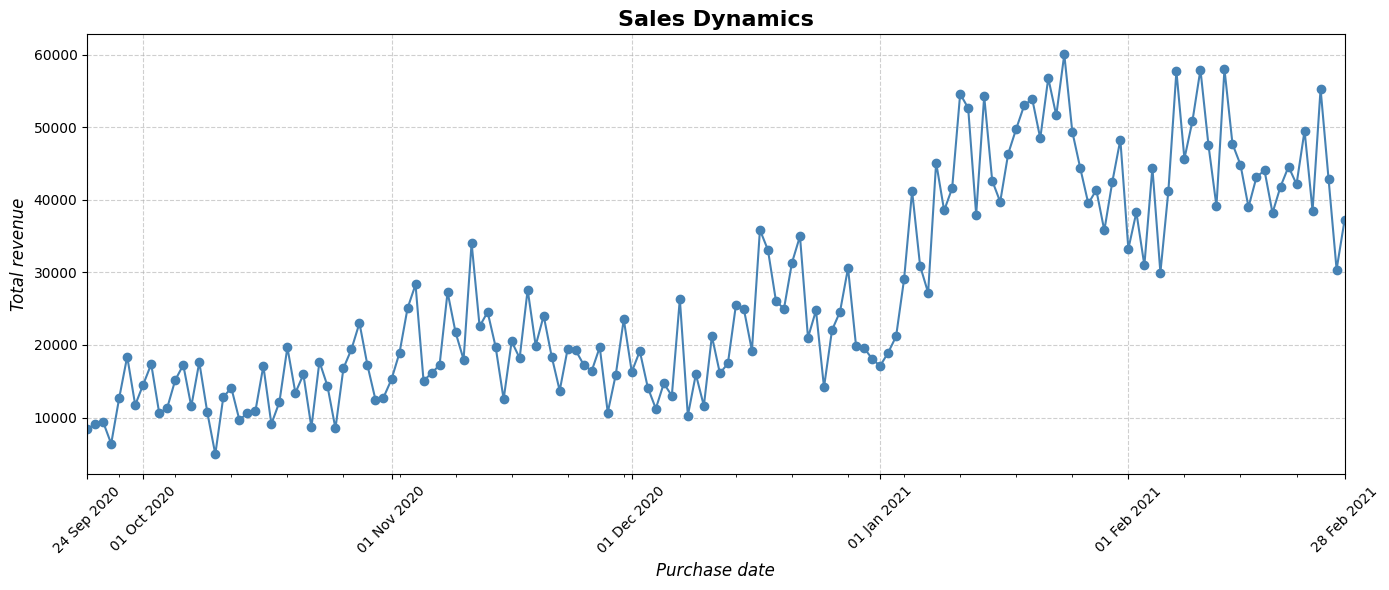

In [27]:
# 5.1.6 Build Graph Sales dynamics

# Group data by date and count sales amount for each day
purchase_by_date = purchases.groupby('event_date')['price'].sum()

# Build graph
plt.figure(figsize=(14, 6))
purchase_by_date.plot(kind='line', marker='o', color='steelblue')

plt.title("Sales Dynamics", fontsize=16, fontweight="bold")
plt.xlabel("Purchase date", fontsize=12, fontstyle="italic")
plt.ylabel("Total revenue", fontsize=12, fontstyle="italic")

# Date formatting
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

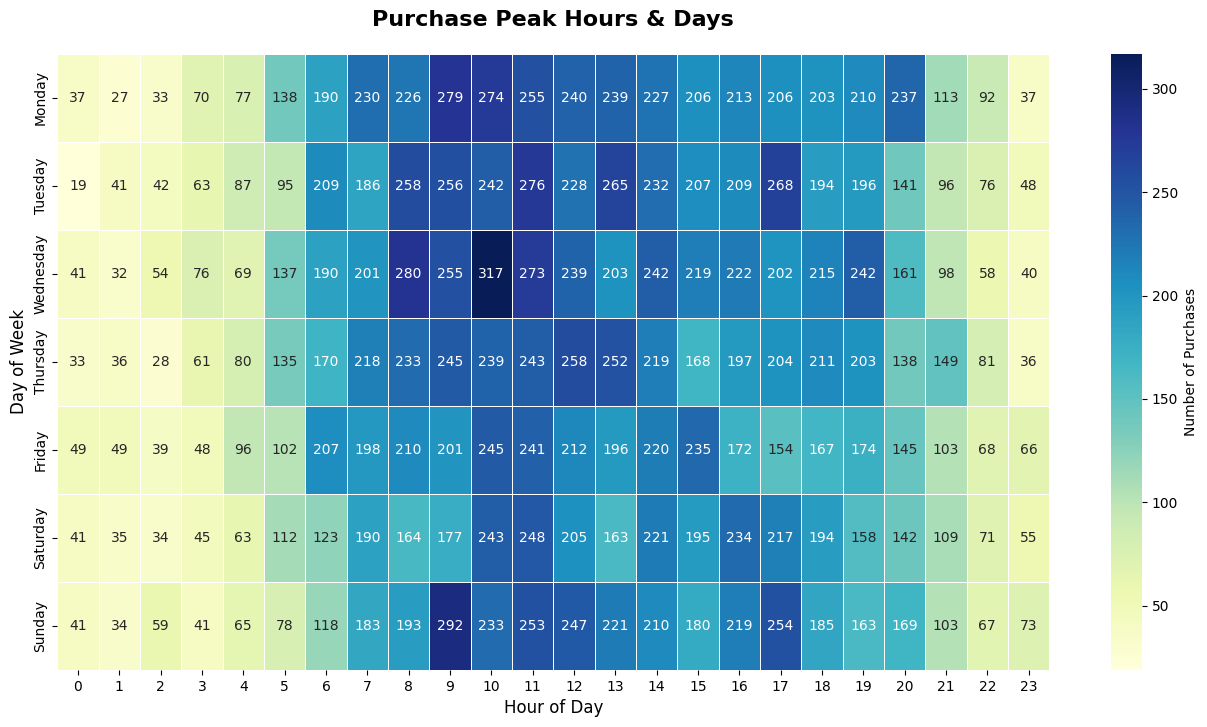

In [28]:
# 5.1.7 Heat map by day of week and event hour
# Count purchase number by day of week, event hour and unique user id
heatmap_data = (purchases.groupby(['day_of_week', 'event_hour'])['user_id'].count().reset_index().rename(columns={'user_id': 'purchase_count'})
)
# Set correct day-of-week order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create Pivot Table
heatmap_pivot = heatmap_data.pivot(index='day_of_week', columns='event_hour', values='purchase_count')

# Resort index according to days of week order list
heatmap_pivot = heatmap_pivot.reindex(days_order)

# 3. Build heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_pivot, annot=True, fmt='g', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Number of Purchases'})

plt.title('Purchase Peak Hours & Days', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

plt.show()

### Conclusions

**Overall Metrics**
- Total revenue for the period: **$4,290,938**
- Conversion rate: **6.2%** — every 16th session results in a purchase

**Conversion Rate by Category**
- Highest CR in the **computers** category **(7.34%)**, indicating a highly targeted audience
- **Stationery (6.45%)** — above average, despite low traffic volume
- **Accessories (2.90%)** — lowest conversion rate, potentially indicating issues with product range or pricing

**Average Order Value (AOV) and Revenue Per Visitor (RPV)**
- **Computers** leads both metrics: AOV — 340, RPV — 24.96
- **Electronics and Stationery** have similar RPV (~4) despite a significant difference in AOV
- **Accessories** — lowest RPV (1.59), confirming low category performance

**Sales Dynamics**
- A clear upward trend is observed from September 2020 to February 2021
- From January 2021, average daily revenue increased approximately 4–6× compared
  to September–October 2020 (from ~10K to ~40–60K per day)

**Peak Hours and Days (Heatmap)**
- Most active purchase hours: **9:00–15:00** on weekdays
- Peak on Wednesday at 10:00 (317 purchases) — the highest figure across the entire week
- Weekends show lower activity, especially during morning and evening hours

##5.2. Acquisition and Retention Success





In [29]:
# 5.2.1 Rolling Retention (30-day window)
# Identifying user's first activity date (acquisition date)
user_registration = df_it.groupby('user_id')['event_date'].min().reset_index()
user_registration.columns = ['user_id', 'registration_date']

# Selecting all user activities to track returns
sessions = df_it[['user_id', 'event_date']].copy()

# Mapping activities to the acquisition date
merged = sessions.merge(user_registration, on='user_id')

# Filtering returns within the 1-30 day window
merged['days_since_reg'] = (merged['event_date'] - merged['registration_date']).dt.days
returned = merged[(merged['days_since_reg'] >= 1) & (merged['days_since_reg'] <= 30)]

# Identifying unique returning users
returned_users = returned['user_id'].unique()

# Cohort - registration month
user_registration['cohort'] = user_registration['registration_date'].dt.to_period('M')
user_registration['returned'] = user_registration['user_id'].isin(returned_users)

# Calculating Rolling Retention by monthly cohorts
cohort_retention = user_registration.groupby('cohort').agg(total_users=('user_id', 'nunique'), returned_users=('returned', 'sum')).reset_index()
cohort_retention['rolling_retention_30d_%'] = (cohort_retention['returned_users'] / cohort_retention['total_users'] * 100).round(2)

print(cohort_retention)

    cohort  total_users  returned_users  rolling_retention_30d_%
0  2020-09         7902             772                     9.77
1  2020-10        44471            3277                     7.37
2  2020-11        48397            3593                     7.42
3  2020-12        38612            3084                     7.99
4  2021-01        46286            4451                     9.62
5  2021-02        41631            2671                     6.42


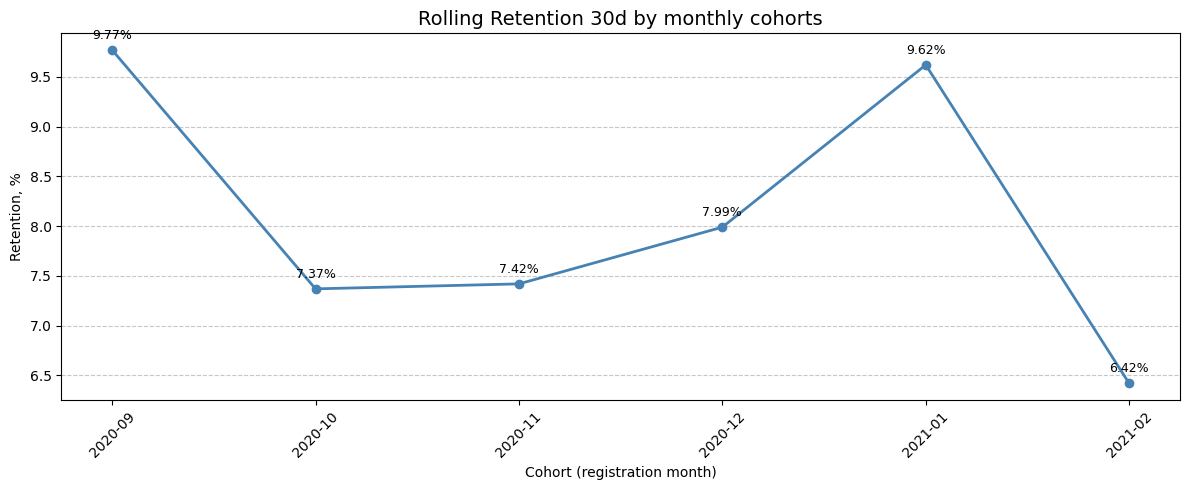

In [30]:
# 5.2.2 Build graph Rolling Retention by monthly cohorts
plt.figure(figsize=(12, 5))
plt.plot(
    cohort_retention['cohort'].astype(str),
    cohort_retention['rolling_retention_30d_%'],
    marker='o', linewidth=2, color='steelblue'
)

for x, y in zip(cohort_retention['cohort'].astype(str), cohort_retention['rolling_retention_30d_%']):
    plt.annotate(f'{y}%', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

plt.title('Rolling Retention 30d by monthly cohorts', fontsize=14)
plt.xlabel('Cohort (registration month)')
plt.ylabel('Retention, %')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
# 5.2.3 LTV (Lifetime Value)
# Acquisition date = user's first appearance
user_registration = df_it.groupby('user_id')['event_date'].min().reset_index()
user_registration.columns = ['user_id', 'registration_date']

# Defining quarterly cohorts
user_registration['cohort_quarter'] = user_registration['registration_date'].dt.to_period('Q')

# Selecting purchase events only
purchases = df_it[df_it['event_type'] == 'purchase'][['user_id', 'event_date', 'price']].copy()

# Merging purchases with acquisition dates
merged = purchases.merge(user_registration, on='user_id')

# Calculating days from registration to purchase
merged['days_since_reg'] = (merged['event_date'] - merged['registration_date']).dt.days

# Determining max date to check cohort maturity
max_date = df_it['event_date'].max()

# Calculating LTV by cohorts
results = []

for cohort, group in user_registration.groupby('cohort_quarter'):
    total_users = group['user_id'].nunique()
    cohort_end = group['registration_date'].max()  # last registration in cohort

    ltv_30d = None
    ltv_90d = None

    # LTV 30d — available if 30 days have passed
    if (max_date - cohort_end).days >= 30:
        revenue_30d = merged[
            (merged['cohort_quarter'] == cohort) &
            (merged['days_since_reg'] >= 0) &
            (merged['days_since_reg'] <= 30)
        ]['price'].sum()
        ltv_30d = round(revenue_30d / total_users, 2)

    # LTV 90d — available if 90 days have passed
    if (max_date - cohort_end).days >= 90:
        revenue_90d = merged[
            (merged['cohort_quarter'] == cohort) &
            (merged['days_since_reg'] >= 0) &
            (merged['days_since_reg'] <= 90)
        ]['price'].sum()
        ltv_90d = round(revenue_90d / total_users, 2)

    results.append({
        'cohort_quarter': str(cohort),
        'total_users': total_users,
        'ltv_30d': ltv_30d,
        'ltv_90d': ltv_90d
    })

# Creating final LTV dataframe
ltv_df = pd.DataFrame(results)
print(ltv_df)

  cohort_quarter  total_users  ltv_30d  ltv_90d
0         2020Q3         7902    12.23    13.02
1         2020Q4       131480    12.76      NaN
2         2021Q1        87917      NaN      NaN


In [32]:
# 5.2.4 ARPPU Analysis- analyzing the monetization of the customer base
# (using merged and max_date from LTV block above)

results = []

for cohort, group in user_registration.groupby('cohort_quarter'):
    cohort_end = group['registration_date'].max()
    days_available = (max_date - cohort_end).days

    arppu_30d = None
    arppu_90d = None

    # ARPPU 30d — available if 30 days have passed
    if days_available >= 30:
        cohort_purchases_30d = merged[
            (merged['cohort_quarter'] == cohort) &
            (merged['days_since_reg'] >= 0) &
            (merged['days_since_reg'] <= 30)
        ]
        revenue_30d = cohort_purchases_30d['price'].sum()
        paying_users_30d = cohort_purchases_30d['user_id'].nunique()

        if paying_users_30d > 0: # Division by zero protection
            arppu_30d = round(revenue_30d / paying_users_30d, 2)

    # ARPPU 90d — available if 90 days have passed
    if days_available >= 90:
        cohort_purchases_90d = merged[
            (merged['cohort_quarter'] == cohort) &
            (merged['days_since_reg'] >= 0) &
            (merged['days_since_reg'] <= 90)
        ]
        revenue_90d = cohort_purchases_90d['price'].sum()
        paying_users_90d = cohort_purchases_90d['user_id'].nunique()

        if paying_users_90d > 0:
            arppu_90d = round(revenue_90d / paying_users_90d, 2)

    results.append({
        'cohort_quarter': str(cohort),
        'arppu_30d': arppu_30d,
        'arppu_90d': arppu_90d
    })

# Creating final ARPPU dataframe
arppu_df = pd.DataFrame(results)
print(arppu_df)


  cohort_quarter  arppu_30d  arppu_90d
0         2020Q3     207.89     217.98
1         2020Q4     209.57        NaN
2         2021Q1        NaN        NaN


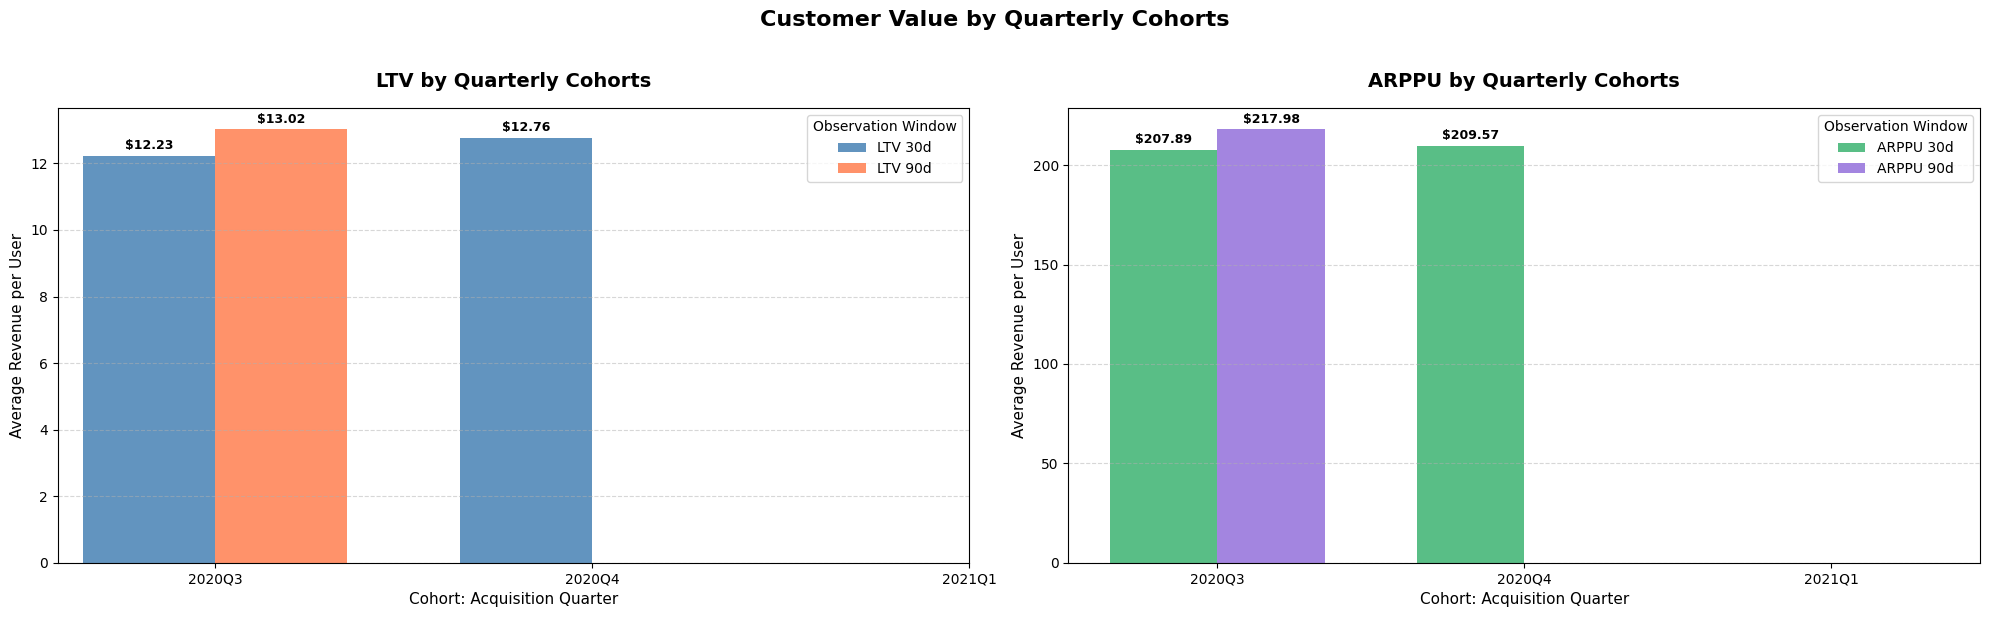

In [33]:
# 5.2.5 Visualizing LTV and ARPPU by quarterly cohorts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

x1 = np.arange(len(ltv_df))
x2 = np.arange(len(arppu_df))
width = 0.35

# --- LTV ---
bars1 = ax1.bar(x1 - width/2, ltv_df['ltv_30d'], width, label='LTV 30d', color='steelblue', alpha=0.85)
bars2 = ax1.bar(x1 + width/2, ltv_df['ltv_90d'], width, label='LTV 90d', color='coral', alpha=0.85)

for bar in bars1:
    height = bar.get_height()
    if pd.notna(height) and height > 0:
        ax1.annotate(f'${height:.2f}',
                     xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    if pd.notna(height) and height > 0:
        ax1.annotate(f'${height:.2f}',
                     xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

ax1.set_title('LTV by Quarterly Cohorts', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Cohort: Acquisition Quarter', fontsize=11)
ax1.set_ylabel('Average Revenue per User', fontsize=11)
ax1.set_xticks(x1)
ax1.set_xticklabels(ltv_df['cohort_quarter'], rotation=0)
ax1.legend(title='Observation Window')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- ARPPU ---
bars3 = ax2.bar(x2 - width/2, arppu_df['arppu_30d'].fillna(0), width, label='ARPPU 30d', color='mediumseagreen', alpha=0.85)
bars4 = ax2.bar(x2 + width/2, arppu_df['arppu_90d'].fillna(0), width, label='ARPPU 90d', color='mediumpurple', alpha=0.85)

for bar, val in zip(bars3, arppu_df['arppu_30d']):
    if pd.notna(val) and val > 0:
        ax2.annotate(f'${val:.2f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

for bar, val in zip(bars4, arppu_df['arppu_90d']):
    if pd.notna(val) and val > 0:
        ax2.annotate(f'${val:.2f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

ax2.set_title('ARPPU by Quarterly Cohorts', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Cohort: Acquisition Quarter', fontsize=11)
ax2.set_ylabel('Average Revenue per User', fontsize=11)
ax2.set_xticks(x2)
ax2.set_xticklabels(arppu_df['cohort_quarter'], rotation=0)
ax2.legend(title='Observation Window')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Customer Value by Quarterly Cohorts', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# 5.2.6 ARPPU transactional
# Monthly ARPPU
# Selecting only purchase events
purchases = df_it[df_it['event_type'] == 'purchase'][['user_id', 'event_date', 'price', 'month']].copy()
# Sort months in chronological order
purchases['month_order'] = pd.to_datetime(purchases['month'], format='%b %Y')

# Grouping by month and calculating metrics
arppu_monthly = purchases.groupby('month_order').agg(
    month=('month', 'first'),
    revenue=('price', 'sum'),
    paying_users=('user_id', 'nunique')
).reset_index(drop=True)

# Calculating Monthly ARPPU
arppu_monthly['arppu'] = (arppu_monthly['revenue'] / arppu_monthly['paying_users']).round(2)

print("Monthly ARPPU:")
print(arppu_monthly)

# Quarterly ARPPU

# Extracting quarter from event date
purchases['quarter'] = pd.to_datetime(purchases['event_date']).dt.to_period('Q')

# Grouping by quarter
arppu_quarterly = purchases.groupby('quarter').agg(
    revenue=('price', 'sum'),
    paying_users=('user_id', 'nunique')
).reset_index()

# Formatting and calculating Quarterly ARPPU
arppu_quarterly['quarter'] = arppu_quarterly['quarter'].astype(str)
arppu_quarterly['arppu'] = (arppu_quarterly['revenue'] / arppu_quarterly['paying_users']).round(2)

print("\nQuarterly ARPPU:")
print(arppu_quarterly)

Monthly ARPPU:
      month     revenue  paying_users   arppu
0  Sep 2020    76129.41           421  180.83
1  Oct 2020   427389.16          2545  167.93
2  Nov 2020   601097.44          2955  203.42
3  Dec 2020   658198.12          2690  244.68
4  Jan 2021  1313804.32          3574  367.60
5  Feb 2021  1214320.46          3200  379.48

Quarterly ARPPU:
  quarter     revenue  paying_users   arppu
0  2020Q3    76129.41           421  180.83
1  2020Q4  1686684.72          8074  208.90
2  2021Q1  2528124.78          6674  378.80


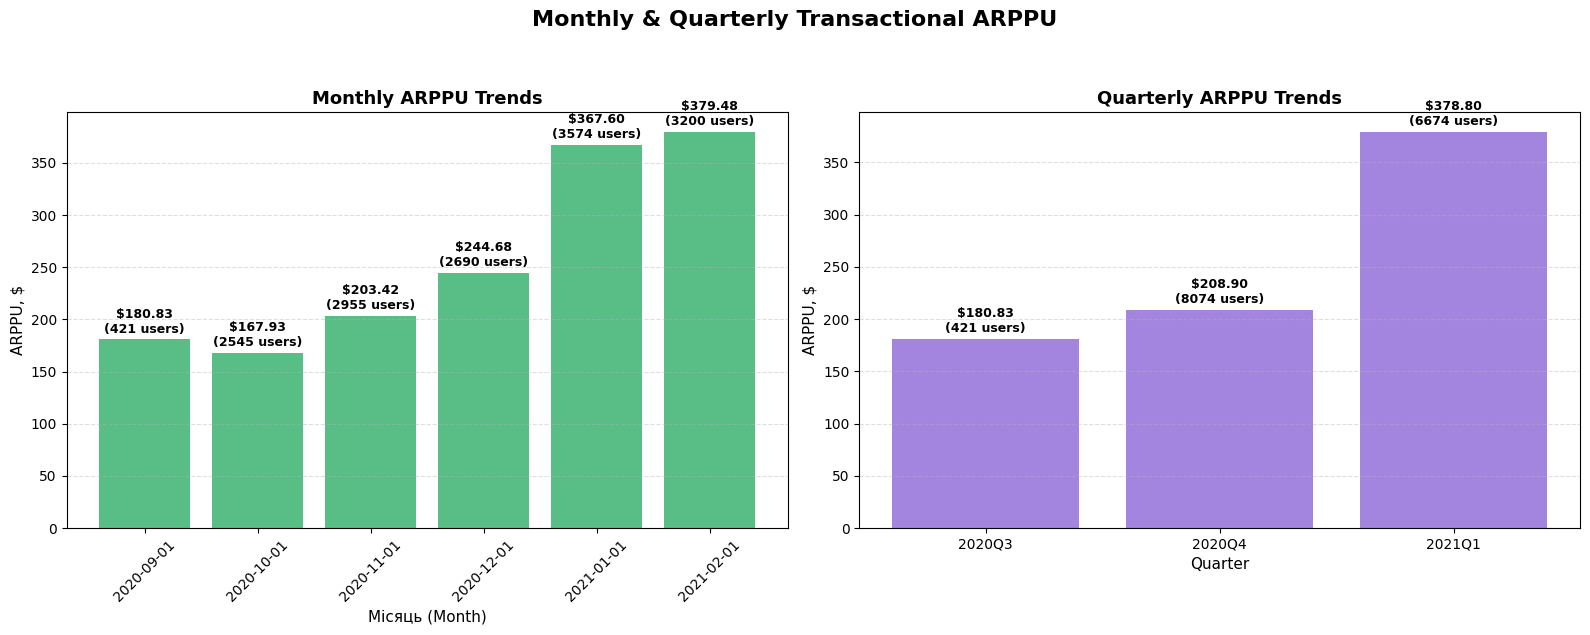

In [35]:
# 5.2.7 Visualization of Monthly & Quarterly ARPPU

# sort months in chronological order
arppu_monthly['month'] = pd.to_datetime(arppu_monthly['month'], format='%b %Y')
arppu_monthly = arppu_monthly.sort_values('month').reset_index(drop=True)
month_labels = arppu_monthly['month'].dt.strftime('%b %Y')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Monthly ARPPU


axes[0].bar(arppu_monthly['month'].astype(str), arppu_monthly['arppu'],
            color='mediumseagreen', alpha=0.85)

# Adding annotations with ARPPU and User count
for i, (val, users) in enumerate(zip(arppu_monthly['arppu'], arppu_monthly['paying_users'])):
    axes[0].annotate(f'${val:.2f}\n({users} users)',
                     xy=(i, val), xytext=(0, 5),
                     textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

axes[0].set_title('Monthly ARPPU Trends', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Місяць (Month)', fontsize=11)
axes[0].set_ylabel('ARPPU, $', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Chart 2: Quarterly ARPPU
axes[1].bar(arppu_quarterly['quarter'], arppu_quarterly['arppu'],
            color='mediumpurple', alpha=0.85)

for i, (val, users) in enumerate(zip(arppu_quarterly['arppu'], arppu_quarterly['paying_users'])):
    axes[1].annotate(f'${val:.2f}\n({users} users)',
                     xy=(i, val), xytext=(0, 5),
                     textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('Quarterly ARPPU Trends', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quarter', fontsize=11)
axes[1].set_ylabel('ARPPU, $', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Main Title
plt.suptitle('Monthly & Quarterly Transactional ARPPU',
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

### Conclusions

**Rolling Retention (30d)**
- Average 30-day retention rate: ~8%
- Highest retention in September 2020 (9.77%) and January 2021 (9.62%); lowest in February 2021 (6.42%)

**LTV by Cohort**
- 30-day LTV is stable: Q3 2020 cohort — 12.23, Q4 2020 — 12.76
- 90-day LTV is available only for Q3 2020 (13.02) — minimal growth compared to 30d,
indicating low repeat activity after the first month
- Q4 2020 and Q1 2021 do not yet have complete data for 90-day observation

**ARPPU by Cohort**
- Average revenue per paying user is stable: Q3 2020 — $207.89, Q4 2020 — 209.57
- Growth between 30d and 90d for Q3 2020 is minimal (207 → 217) — most purchases occur within the first 30 days

**Monthly & Quarterly ARPPU**
- Clear upward trend: Q3 2020 — 180 → Q4 2020 — 208 → Q1 2021 — 378 (+81% over two quarters)
- Peak in February 2021 (379) — possibly driven by seasonality or a shift in buyer composition
- Rising ARPPU with stable cohort LTV suggests that new users are purchasing more expensive
items rather than buying more frequently

Although February shows a decline in Retention Rate, it simultaneously records a peak ARPPU ($379). This may indicate a strategic shift: fewer users are being acquired, but they are spending significantly larger amounts.



##5.3 Purchase Funnel Optimization

In [36]:
# 5.3.1 Calculating the overall sales funnel based on unique users

funnel = df_it.groupby('event_type')['user_id'].nunique().sort_values(ascending=False).reset_index()
funnel.columns = ['stage', 'users']

# 1. Funnel CR: conversion relative to the top of the funnel
funnel['funnel_cr_%'] = (funnel['users'] / funnel['users'].iloc[0] * 100).round(2)

# 2. Step Conversion: conversion relative to the previous stage
funnel['step_cr_%'] = (funnel['users'] / funnel['users'].shift(1) * 100).round(2)

# 3. Drop-off: percentage of users lost at each step
funnel['drop_off_%'] = (100 - funnel['step_cr_%']).round(2)

print("Global User Funnel:\n")
print(funnel)


Global User Funnel:

      stage   users  funnel_cr_%  step_cr_%  drop_off_%
0      view  227020       100.00        NaN         NaN
1      cart   26262        11.57      11.57       88.43
2  purchase   15055         6.63      57.33       42.67


In [37]:
# 5.3.2 Sales Funnel Visualization
# Sales funnel data
stages = ['View', 'Cart', 'Purchase']

# Getting values from dataframe
event_counts = df_it['event_type'].value_counts()
users = [
    event_counts.get('view', 0),
    event_counts.get('cart', 0),
    event_counts.get('purchase', 0)
]

# Creating funnel chart
fig = go.Figure(go.Funnel(
    y = stages,
    x = users,
    textinfo = "value+percent initial",
    textfont = {"size": 13, "color": "white", "family": "Arial Black"},
    marker = {"color": ["#636EFA", "#AB63FA", "#19D3F3"]}
))

# Setting title and layout
fig.update_layout(
    title_text = 'Sales Funnel',
    title_x = 0.5,
    title_font = {"size": 16, "family": "Arial Black"},
    funnelmode = "stack"
)

fig.show()

In [38]:
# 5.3.3 Monthly Funnel Conversion Analysis
# Create month label
df_it['month_label'] = pd.to_datetime(df_it['event_date']).dt.strftime('%b %Y')

# Group by month and event type, count unique sessions
monthly_funnel = df_it.groupby(['month_label', 'event_type'])['user_session'].nunique().unstack(fill_value=0).reset_index()

# Sort months in chronological order
monthly_funnel['month_order'] = pd.to_datetime(monthly_funnel['month_label'], format='%b %Y')
monthly_funnel = monthly_funnel.sort_values('month_order').reset_index(drop=True)

monthly_funnel.columns.name = None

# Add missing columns if needed
for col in ['view', 'cart', 'purchase']:
    if col not in monthly_funnel.columns:
        monthly_funnel[col] = 0

# Calculate conversion rate between funnel stages
monthly_funnel['step_cr_view_cart_%']     = (monthly_funnel['cart'] / monthly_funnel['view'] * 100).round(2)
monthly_funnel['step_cr_cart_purchase_%'] = (monthly_funnel['purchase'] / monthly_funnel['cart'] * 100).round(2)
monthly_funnel['funnel_cr_%']             = (monthly_funnel['purchase'] / monthly_funnel['view'] * 100).round(2)

# Print monthly funnel
print("\nMonthly Funnel:\n")
print(monthly_funnel[['month_label', 'view', 'cart', 'purchase',
                       'step_cr_view_cart_%', 'step_cr_cart_purchase_%', 'funnel_cr_%']])


Monthly Funnel:

  month_label   view  cart  purchase  step_cr_view_cart_%  \
0    Sep 2020   8855   733       450                 8.28   
1    Oct 2020  51423  4567      2795                 8.88   
2    Nov 2020  58778  5521      3374                 9.39   
3    Dec 2020  48108  5136      3021                10.68   
4    Jan 2021  59669  7311      4098                12.25   
5    Feb 2021  53476  6511      3666                12.18   

   step_cr_cart_purchase_%  funnel_cr_%  
0                    61.39         5.08  
1                    61.20         5.44  
2                    61.11         5.74  
3                    58.82         6.28  
4                    56.05         6.87  
5                    56.30         6.86  


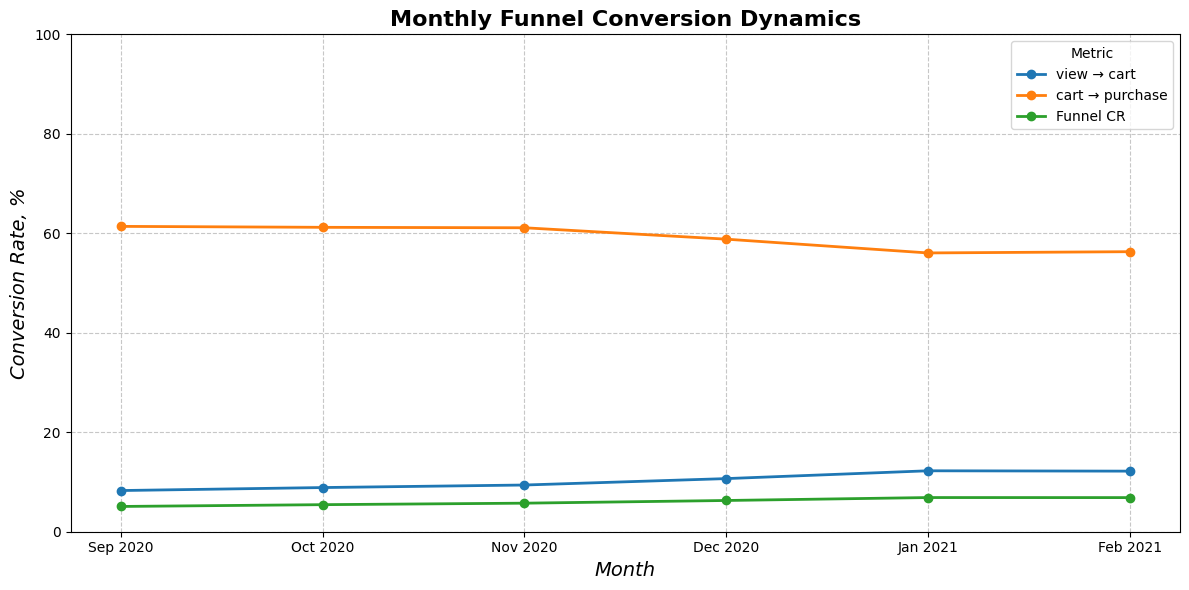

In [39]:
# 5.3.4 Funnel Conversion Dynamics Visualization
# Chart data
metrics = ['step_cr_view_cart_%', 'step_cr_cart_purchase_%', 'funnel_cr_%']
labels = ['view → cart', 'cart → purchase', 'Funnel CR']

# Building funnel conversion dynamics chart
plt.figure(figsize=(12, 6))

colors = sns.color_palette('tab10', n_colors=len(metrics))
color_map = dict(zip(metrics, colors))

for metric, label in zip(metrics, labels):
    plt.plot(
        monthly_funnel['month_label'].astype(str),
        monthly_funnel[metric],
        label=label,
        marker='o',
        color=color_map.get(metric),
        linewidth=2
    )

plt.xlabel("Month", fontsize=14, fontstyle="italic")
plt.ylabel("Conversion Rate, %", fontsize=14, fontstyle="italic")
plt.title("Monthly Funnel Conversion Dynamics",
          fontsize=16, fontweight="bold")
plt.ylim(0, 100)
plt.legend(title="Metric")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [40]:
# 5.3.5 Time -to-Purchase analysis
# First appearance
first_visit = df_it.groupby('user_id')['event_date'].min().reset_index()
first_visit.columns = ['user_id', 'first_visit_date']

# First purchase
first_purchase = df_it[df_it['event_type'] == 'purchase'].groupby('user_id')['event_date'].min().reset_index()
first_purchase.columns = ['user_id', 'first_purchase_date']

# Merging visit and purchase data
ttp_df = first_purchase.merge(first_visit, on='user_id')

# Calculating difference in days
ttp_df['days_to_purchase'] = (ttp_df['first_purchase_date'] - ttp_df['first_visit_date']).dt.days

# Adding purchase month for trend analysis
ttp_df['purchase_month'] = ttp_df['first_purchase_date'].dt.to_period('M')

# Aggregating: mean and median time to purchase by month
ttp_stats = ttp_df.groupby('purchase_month')['days_to_purchase'].agg(['mean', 'median', 'count']).reset_index()

# Rounding for clarity
ttp_stats['mean'] = ttp_stats['mean'].round(2)
ttp_stats['purchase_month'] = ttp_stats['purchase_month'].astype(str)

print("  Time-to-Purchase Stats:\n")
print(ttp_stats)

  Time-to-Purchase Stats:

  purchase_month  mean  median  count
0        2020-09  0.07     0.0    421
1        2020-10  0.54     0.0   2528
2        2020-11  0.98     0.0   2899
3        2020-12  1.33     0.0   2627
4        2021-01  1.78     0.0   3499
5        2021-02  2.43     0.0   3081


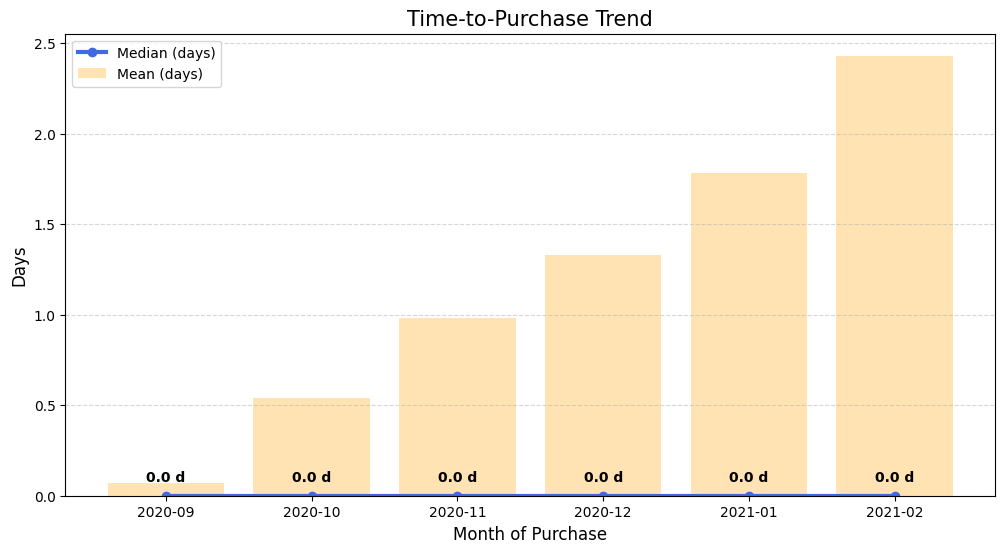

In [41]:
# 5.3.6 Build graph Time-to-Purchase Trend

fig, ax = plt.subplots(figsize=(12, 6))

# Plotting median time trend
ax.plot(ttp_stats['purchase_month'], ttp_stats['median'], marker='o', linestyle='-',
        linewidth=3, color='royalblue', label='Median (days)')
ax.bar(ttp_stats['purchase_month'], ttp_stats['mean'], alpha=0.3,
       color='orange', label='Mean (days)')

# Data labels
for i, txt in enumerate(ttp_stats['median']):
    ax.annotate(f'{txt} d', (ttp_stats['purchase_month'][i], ttp_stats['median'][i]),
                textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

ax.set_title('Time-to-Purchase Trend', fontsize=15)
ax.set_ylabel('Days', fontsize=12)
ax.set_xlabel('Month of Purchase', fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Conclusions

**Global User Funnel**
- Out of 227,020 unique users, only **11.6%** added a product to the cart
- Of those who added to cart, **57.3%** completed a purchase — a relatively high rate
- The main drop-off occurs at the **view → cart stage (88.4% drop-off)** —
users browse but are not sufficiently engaged to add items to the cart

**Monthly Conversion Dynamics**
- **View → cart** conversion is steadily growing: from 8.3% (September 2020) to 12.2% (February 2021) —
the store is becoming more effective at attracting engaged shoppers
- **Cart → purchase** conversion is declining: from 61.4% to 56.3% —
a growing number of users add items to the cart but do not complete the purchase
- Overall **Funnel CR** is increasing: 5.1% → 6.9% — a positive trend

**Time-to-Purchase**
- Median = 0 across all months — most users purchase on the day of their first visit
- Average time to purchase is gradually increasing: 0.07 days (September) → 2.43 days (February) —
users are increasingly deliberating before making a purchase. This may indicate:
  - a growing share of high-value products (videocards) where decisions take longer
  - rising prices prompting users to compare offers before purchasing

#5.4. Product Assortment Analysis

In [42]:
# 5.4.1 Revenue analysis by product categories
# Filtering only purchase events
purchases = df_it[df_it['event_type'] == 'purchase']
total_purchases = purchases['price'].sum()

# Grouping by main categories
category_revenue = purchases.groupby('main_category')['price'].sum().sort_values(ascending=False).reset_index()

# Calculating percentage of total revenue
category_revenue['% of total'] = (category_revenue["price"] / total_purchases * 100).round(2)

#  Formatting and displaying results
category_revenue.columns = ['Category', 'Revenue', '% of total']
print(f' Revenue by product categories:\n\n {category_revenue}')
print(f'\nTotal revenue:  {total_purchases}')


 Revenue by product categories:

       Category     Revenue  % of total
0    computers  3728835.55       86.90
1  electronics   450348.57       10.50
2   stationery   109670.38        2.56
3  accessories     2084.41        0.05

Total revenue:  4290938.91


In [43]:
# 5.4.2 Orders number analysis by categories
# Using the purchase dataframe
purchases = df_it[df_it['event_type'] == 'purchase']
total_count = len(purchases)

# Grouping by number of transactions
category_count = purchases.groupby('main_category')['price'].count().sort_values(ascending=False).reset_index()

# Calculating percentage of total orders
category_count['% of total'] = (category_count['price'] / total_count * 100).round(2)

# Formatting and output
category_count.columns = ['Category', 'Orders', '% of total']
print(f' Orders number by categories:\n\n {category_count}')
print(f'\nTotal orders:  {total_count}')


 Orders number by categories:

       Category  Orders  % of total
0    computers   16870       63.39
1  electronics    6768       25.43
2   stationery    2919       10.97
3  accessories      56        0.21

Total orders:  26613


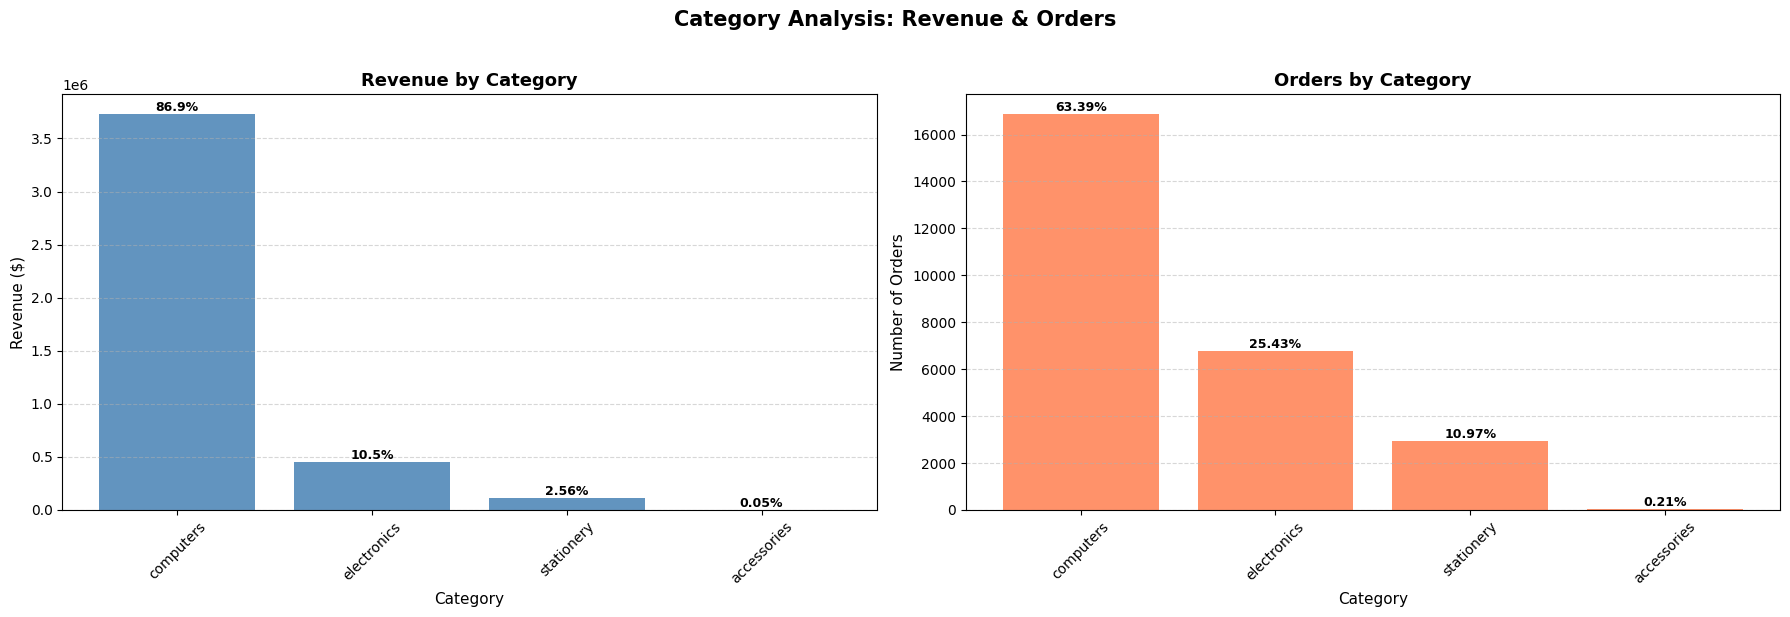

In [44]:
# 5.4.3 Revenue and Orders by Category Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Revenue by Category--
bars1 = ax1.bar(
    category_revenue['Category'],
    category_revenue['Revenue'],
    color='steelblue',
    alpha=0.85
)

for bar, pct in zip(bars1, category_revenue['% of total']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

ax1.set_title('Revenue by Category', fontsize=13, fontweight='bold')
ax1.set_xlabel('Category', fontsize=11)
ax1.set_ylabel('Revenue ($)', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Chart 2: Orders by Category
bars2 = ax2.bar(
    category_count['Category'],
    category_count['Orders'],
    color='coral',
    alpha=0.85
)

for bar, pct in zip(bars2, category_count['% of total']):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

ax2.set_title('Orders by Category', fontsize=13, fontweight='bold')
ax2.set_xlabel('Category', fontsize=11)
ax2.set_ylabel('Number of Orders', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Category Analysis: Revenue & Orders',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

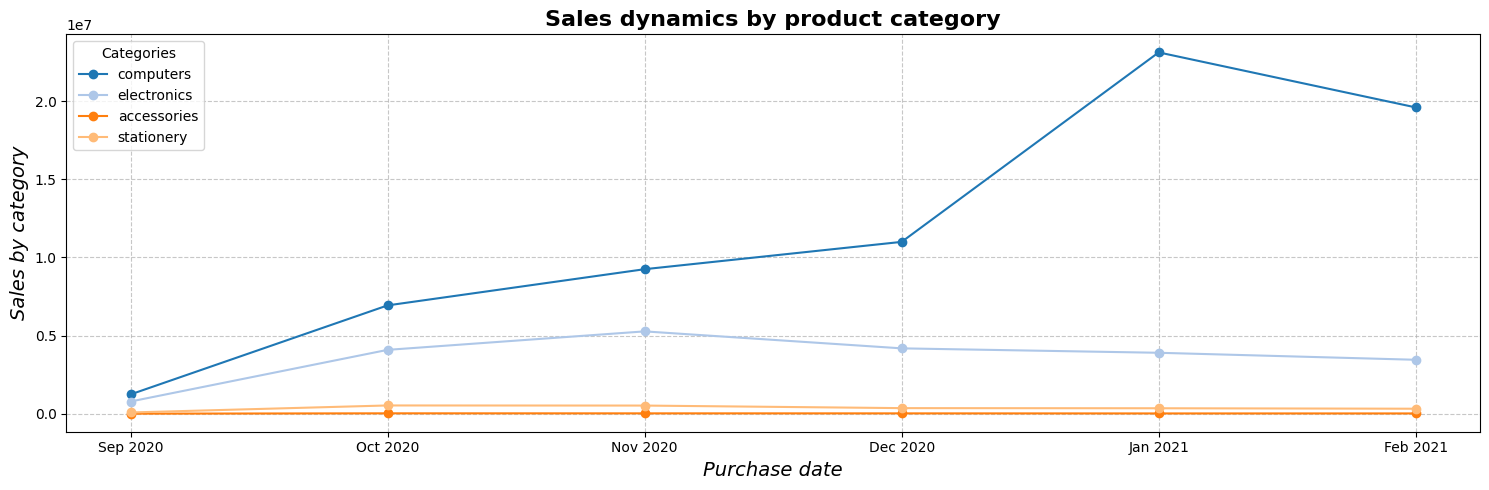

In [45]:
# 5.4.4 Build graph Sales dynamics by categories
# Grouping by category and month
categ_groped = df_it.groupby(['main_category', 'month_label'])['price'].sum().reset_index()

# Chronological sorting
categ_groped['month_order'] = pd.to_datetime(categ_groped['month_label'], format='%b %Y')
categ_groped = categ_groped.sort_values('month_order')

# Getting unique categories
categories = categ_groped['main_category'].unique()

# Plotting
plt.figure(figsize=(15, 5))

# Color palette
colors = sns.color_palette('tab20', n_colors=len(categories))
color_map = dict(zip(categories, colors))

for category in categories:
    category_data = categ_groped[categ_groped["main_category"] == category]
    plt.plot(category_data["month_label"], category_data["price"], label=category, marker='o', color=color_map.get(category))

plt.xlabel("Purchase date", fontsize=14, fontstyle="italic")
plt.ylabel("Sales by category", fontsize=14, fontstyle="italic")
plt.title("Sales dynamics by product category", fontsize=16, fontweight="bold")
plt.legend(title="Categories")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [46]:
# 5.4.5 TOP 10 products in each category by revenue
# Grouping by category and product type
revenue_categ_prod = (
    df_it[df_it['event_type'] == 'purchase']
    .groupby(['main_category', 'product_type'])['price']
    .sum()
    .reset_index()
    .sort_values(['main_category', 'price'], ascending=[True, False])
)

# Selecting Top 10 for each category
top10_revenue_categ_prod = revenue_categ_prod.groupby('main_category').head(10).copy()

# Calculating total category revenue for accurate percentage
category_total_revenue = df_it[df_it['event_type'] == 'purchase'].groupby('main_category')['price'].sum().reset_index()
category_total_revenue.columns = ['main_category', 'cat_full_price']

# Merging and final calculations
top10_revenue_categ_prod = top10_revenue_categ_prod.merge(category_total_revenue, on='main_category')

# Product's share in its category revenue
top10_revenue_categ_prod['% of category'] = (
    top10_revenue_categ_prod['price'] / top10_revenue_categ_prod['cat_full_price'] * 100
).round(1)

# Renaming columns for the report
top10_revenue_categ_prod.columns = [
    'Main Category',
    'Product Type',
    'Revenue',
    'Total Category Revenue',
    '% of category'
]

print("TOP 10 Products by Category:\n")
print(top10_revenue_categ_prod.drop(columns=['Total Category Revenue']))

TOP 10 Products by Category:

   Main Category  Product Type     Revenue  % of category
0    accessories           bag     2084.41          100.0
1      computers    videocards  2604764.80           69.9
2      computers       printer   364566.80            9.8
3      computers           cpu   219168.98            5.9
4      computers   motherboard   102871.16            2.8
5      computers      notebook    63604.79            1.7
6      computers  power_supply    52404.61            1.4
7      computers           hdd    48811.30            1.3
8      computers       monitor    46865.37            1.3
9      computers          wifi    44877.75            1.2
10     computers        ebooks    44338.63            1.2
11   electronics     telephone   150915.69           33.5
12   electronics      acoustic    84724.80           18.8
13   electronics            tv    57987.91           12.9
14   electronics        tablet    53347.43           11.8
15   electronics     projector    52830.41

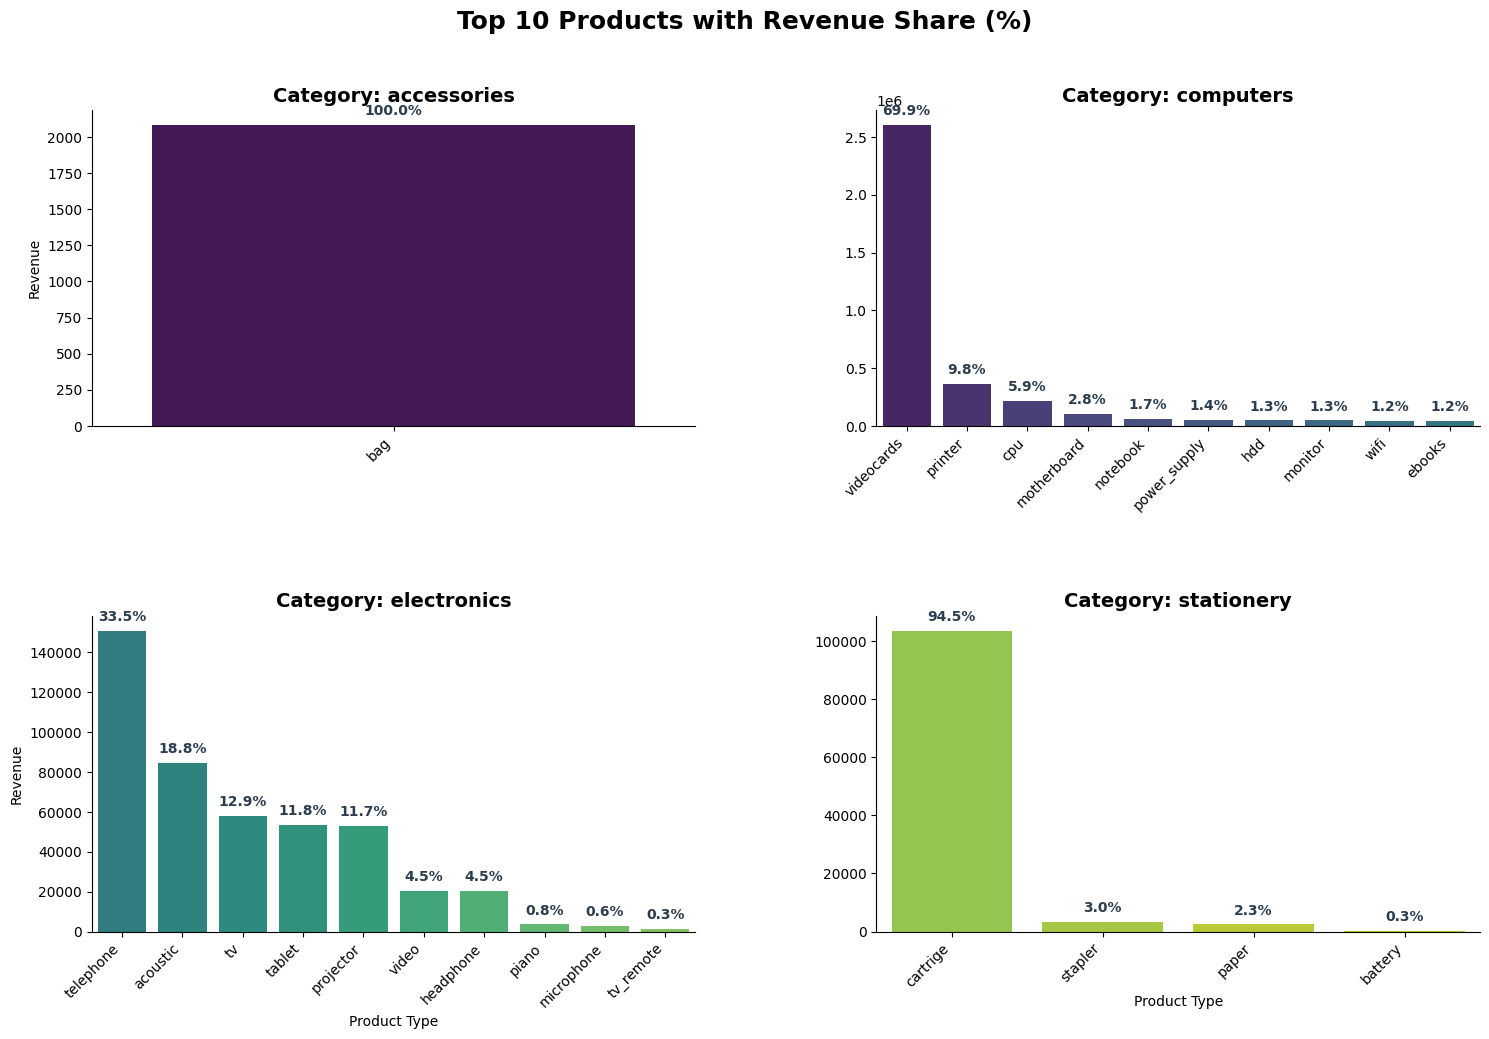

In [47]:

# 5.4.6 Visualization of TOP 10 Products by Category

# Creating the plot
g = sns.catplot(
    data=top10_revenue_categ_prod,
    x="Product Type",
    y="Revenue",
    hue="Product Type",
    kind="bar",
    col="Main Category",
    col_wrap=2,
    height=5,
    aspect=1.5,
    palette="viridis",
    legend=False,
    sharex=False,
    sharey=False
)

# Adding % annotations
for ax in g.axes.flatten():
    # Extracting category name from title
    title = ax.get_title().split('=')[-1].strip()
    curr_data = top10_revenue_categ_prod[top10_revenue_categ_prod['Main Category'] == title]

    for i, p in enumerate(ax.patches):
        if i < len(curr_data):
            percent = curr_data.iloc[i]['% of category']
            ax.annotate(f'{percent}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 10),
                        textcoords='offset points',
                        fontsize=10, fontweight='bold', color='#2c3e50')

# Layout and Label settings
g.fig.subplots_adjust(top=0.88, hspace=0.6, wspace=0.3)

# Axis labels
g.set_axis_labels("Product Type", "Revenue")
g.set_titles("Category: {col_name}", size=14, fontweight='bold')
g.set_xticklabels(rotation=45, horizontalalignment='right')

g.fig.suptitle("Top 10 Products with Revenue Share (%)", fontsize=18, fontweight="bold")

plt.show()




In [48]:
# 5.4.7 Monthly Revenue Dynamics of the Top Product

# Define the top revenue product
top_product = top10_revenue_categ_prod.sort_values('Revenue', ascending=False).iloc[0]['Product Type']
top_category = top10_revenue_categ_prod.sort_values('Revenue', ascending=False).iloc[0]['Main Category']

print(f"Top product: {top_product} | Category: {top_category}")

# Filter purchases by top product
top_product_df = df_it[
    (df_it['event_type'] == 'purchase') &
    (df_it['product_type'] == top_product)
]

# Group by month
top_product_monthly = top_product_df.groupby('month_label').agg(
    revenue=('price', 'sum'),
    orders=('user_session', 'nunique')
).reset_index()

# Sort in chronological order
top_product_monthly['month_order'] = pd.to_datetime(top_product_monthly['month_label'], format='%b %Y')
top_product_monthly = top_product_monthly.sort_values('month_order').reset_index(drop=True)

print("\nMonthly Dynamics:\n")
print(top_product_monthly[['month_label', 'revenue', 'orders']])


Top product: videocards | Category: computers

Monthly Dynamics:

  month_label     revenue  orders
0    Sep 2020    15516.10      26
1    Oct 2020    94747.51     186
2    Nov 2020   207645.64     402
3    Dec 2020   331101.87     640
4    Jan 2021  1002194.45    1864
5    Feb 2021   953559.23    1641


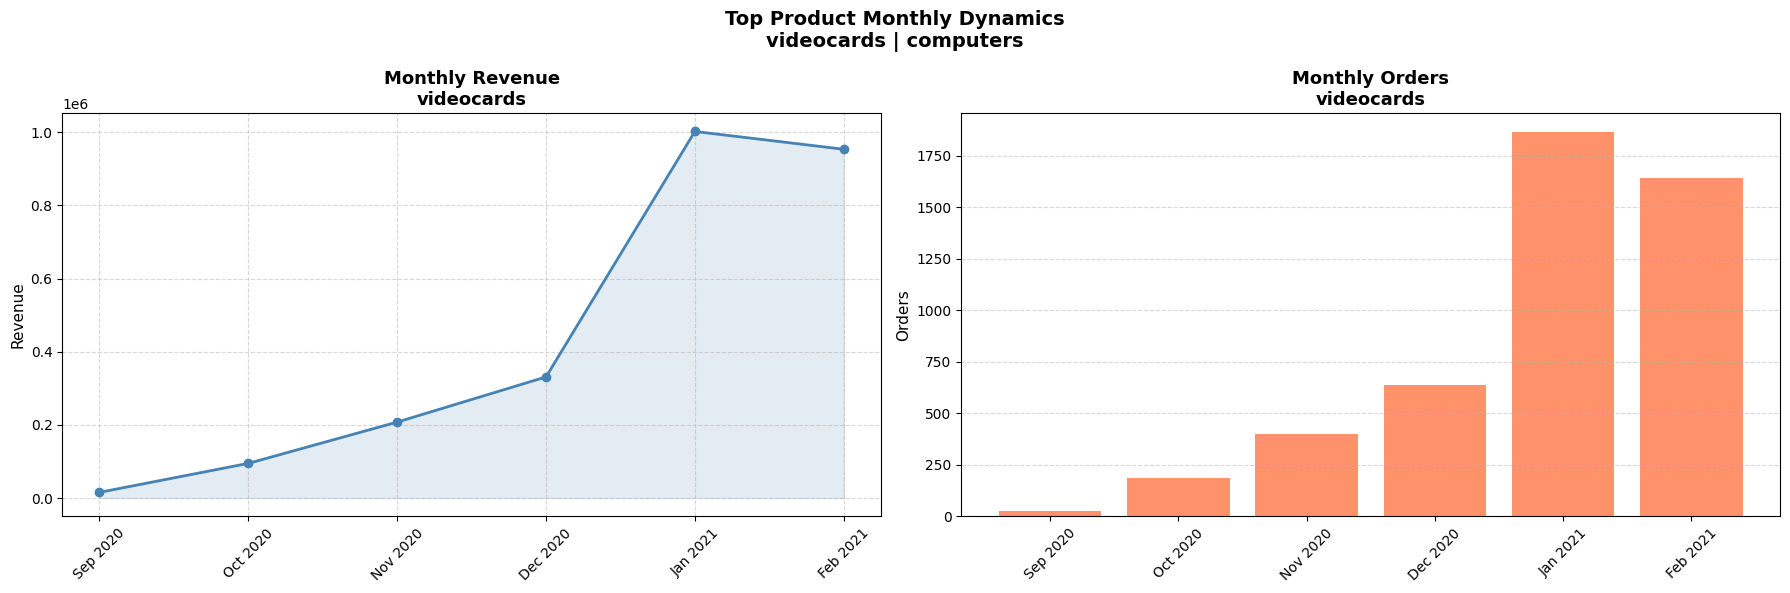

In [49]:
# 5.4.8 Build graphs TOP product monthly revenue & number of orders dynamics

# Chart 1: Monthly Revenue
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.plot(range(len(top_product_monthly)), top_product_monthly['revenue'],
         marker='o', color='steelblue', linewidth=2)
ax1.fill_between(range(len(top_product_monthly)), top_product_monthly['revenue'],
                 alpha=0.15, color='steelblue')
ax1.set_title(f'Monthly Revenue\n{top_product}',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Revenue', fontsize=11)
ax1.set_xticks(range(len(top_product_monthly)))
ax1.set_xticklabels(top_product_monthly['month_label'], rotation=45)
ax1.grid(linestyle='--', alpha=0.5)

# Chart 2: Monthly Orders
ax2.bar(range(len(top_product_monthly)), top_product_monthly['orders'],
        color='coral', alpha=0.85)
ax2.set_title(f'Monthly Orders\n{top_product}',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Orders', fontsize=11)
ax2.set_xticks(range(len(top_product_monthly)))
ax2.set_xticklabels(top_product_monthly['month_label'], rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'Top Product Monthly Dynamics\n{top_product} | {top_category}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
# 5.4.9 Top Product Revenue Share Analysis

# Total store revenue by month
total_monthly_revenue = df_it[df_it['event_type'] == 'purchase'].groupby('month_label')['price'].sum().reset_index()
total_monthly_revenue.columns = ['month_label', 'total_revenue']

# Merge with top product revenue
share_df = top_product_monthly[['month_label', 'revenue', 'month_order']].merge(
    total_monthly_revenue, on='month_label'
)

# Calculate revenue share
share_df['share_%'] = (share_df['revenue'] / share_df['total_revenue'] * 100).round(2)
share_df = share_df.sort_values('month_order').reset_index(drop=True)

print("TOP Product Revenue Share by Month:\n")
print(share_df[['month_label', 'revenue', 'total_revenue', 'share_%']])

TOP Product Revenue Share by Month:

  month_label     revenue  total_revenue  share_%
0    Sep 2020    15516.10       76129.41    20.38
1    Oct 2020    94747.51      427389.16    22.17
2    Nov 2020   207645.64      601097.44    34.54
3    Dec 2020   331101.87      658198.12    50.30
4    Jan 2021  1002194.45     1313804.32    76.28
5    Feb 2021   953559.23     1214320.46    78.53


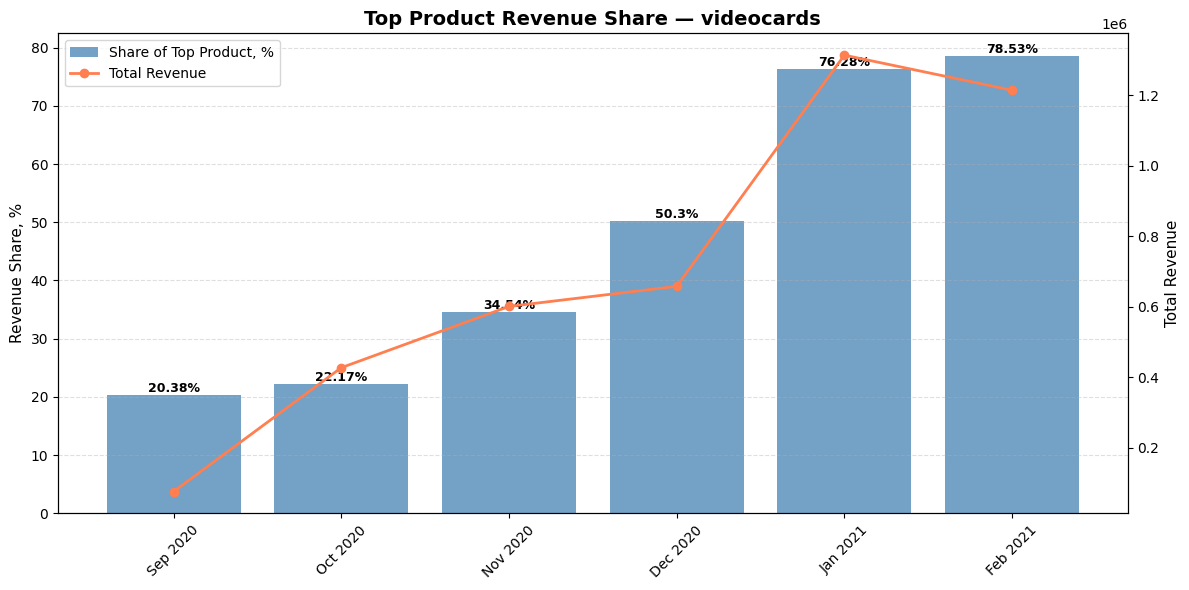

In [51]:
# 5.4.10 Top Product Revenue Share Analysis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars — product share
bars = ax1.bar(range(len(share_df)), share_df['share_%'],
               color='steelblue', alpha=0.75, label='Share of Top Product, %')

# Percentage labels above bars
for bar, val in zip(bars, share_df['share_%']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height(),
             f'{val}%',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax1.set_ylabel('Revenue Share, %', fontsize=11)
ax1.set_xticks(range(len(share_df)))
ax1.set_xticklabels(share_df['month_label'], rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Line — total revenue
ax2 = ax1.twinx()
ax2.plot(range(len(share_df)), share_df['total_revenue'],
         color='coral', marker='o', linewidth=2, label='Total Revenue')
ax2.set_ylabel('Total Revenue', fontsize=11)

# Combined legend for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(f'Top Product Revenue Share — {top_product}',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusions

**Revenue by Category**
- The **computers** category dominates by a wide margin — 86.9% of total revenue ($3.7M)
- **Electronics** ranks second with a 10.5% share (450K)
- **Stationery** and **Accessories** together account for less than 3% — negligible contribution

**Number of Orders by Category**
- Computers also lead in order count (63.4%), but their share of orders (63%)
is significantly lower than their revenue share (87%) — explained by the category's high AOV (340)
- Electronics accounts for 25.4% of orders but only 10.5% of revenue — low average order value

**Top Products**
- The undisputed leader is **videocards**: 69.9% of computers category revenue and ~60%
of total store revenue
- Electronics has no clear dominant product — the top 5 are relatively evenly distributed
(telephone 33.5%, acoustic 18.8%, tv 12.9%)
- In stationery, **cartridge** accounts for 94.5% of category revenue — the category
effectively consists of a single product

**Videocards Dynamics and Revenue Share**
- The share of videocards in total revenue grew month over month: from 20.4% (September 2020)
to 78.5% (February 2021)
- A sharp increase in January 2021 (+$670K vs December) — possibly driven by seasonality
or a videocard market shortage at that time (considering Time-to-Purchase = 0)
- Such high dependency on a single product (~79% of revenue) is a **business risk** —
any supply issues with videocards would critically impact overall revenue

## Overall Conclusions and Recommendations

### Conclusions

**1. Critical dependency on video cards**
The share of videocards in total revenue grew from 20.4% (September 2020) to 78.5%
(February 2021). In January–February 2021, signs of product shortage are observed:
a sharp ARPPU increase to 379, a Retention Rate decline from 9.62% to 6.42%,
while Time-to-Purchase remains close to 0 — buyers are not deliberating but purchasing
immediately, which may indicate fear of missing out.
In February, revenue and order count began to decline (from 1.01M to 953K,
from 1,864 to 1,641 orders), and average daily revenue dropped from ~60K (late January peak)
to ~30–37K by end of February — a possible early sign of demand decline.

**2. Electronics — low conversion despite high traffic**
The category generates 103,702 sessions, but conversion rate of 4.51% is below
the average (6.2%). Starting from November 2020, a negative revenue trend is observed
(decline from ~500K to ~300K). The top 5 products are relatively evenly distributed
with no clear leader — the category requires further analysis.

**3. Stationery — single-product category**
94.5% of category revenue is generated by one product — the ink cartridge.
Conversion rate of 6.45% is above average, indicating stable demand.

**4. Accessories — effectively non-existent category**
0.05% of total revenue, only one product with sales (bag, 56 units over the entire period).
The category is underdeveloped and has no impact on store performance.

**5. Sales funnel**
Overall Funnel CR shows positive dynamics (5.08% → 6.87%).
However, cart → purchase conversion is gradually declining: from 61.4% (September)
to 56.3% (February) — a growing number of users add items to the cart
but do not complete the purchase.

---

### Recommendations

**1. Product assortment diversification**
Dependency on a single product (~79% of revenue) is a critical business risk.
The computers category assortment needs to be expanded: add more CPU, motherboard,
and notebook listings, which are already present but have a minimal share.

**2. Electronics category development**
High traffic with low conversion indicates issues with product range or pricing.
It is recommended to analyze which products are being viewed but not purchased,
and adjust the pricing strategy or expand the product selection.

**3. Stationery category development**
Stable demand for cartridges and above-average conversion rate present
an opportunity to expand the range of complementary products (paper, ink,
office supplies).

**4. Accessories category review**
Reconsider the viability of the category in its current form:
either significantly expand the range of bags and tech accessories,
or reposition the category toward higher-demand complementary products
(cases, cables, chargers) more suited to an IT store.

**5. Cart abandonment strategy**
The gradual decline in cart → purchase conversion requires attention:
consider implementing abandoned cart reminders or additional purchase incentives
(discounts, free shipping).

In [52]:
# Зберігаємо та завантажуємо файл (Save and download file)
df_it.to_csv('df_it.csv', index=False)
files.download('df_it.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Tableau Dashboard https://public.tableau.com/app/profile/iryna.savelieva/viz/Elstore/Dashboard1